In [56]:
!kaggle datasets download -d wordsforthewise/lending-club \
  -f accepted_2007_to_2018Q4.csv.gz

print("✅ Download done!")

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
accepted_2007_to_2018Q4.csv.gz: Skipping, found more recently modified local copy (use --force to force download)
✅ Download done!


In [57]:
import pandas as pd

# Load the compressed file directly — no unzipping needed
df = pd.read_csv('accepted_2007_to_2018Q4.csv.gz',
                  compression='gzip',
                  low_memory=False,
                  nrows=200000)  # ← changed to 200k

print("✅ Data loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

✅ Data loaded!
Shape: (200000, 151)
Columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', '

In [58]:
df.shape
#reads the rows and column

(200000, 151)

In [59]:
df.dtypes.value_counts()
#counts how many columns are of each data type in your DataFrame.

,count
float64,114
object,36
int64,1


In [60]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,140992
Charged Off,35090
Current,22637
Late (31-120 days),785
In Grace Period,347
Late (16-30 days),148
Default,1


# **Exploratory data analysis**

In [61]:
# Keep only Fully Paid and Charged Off rows
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Create binary target: 1 = Default, 0 = No Default
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Verify
df['target'].value_counts()

,count
target,
0,140992
1,35090


In [62]:
# Select relevant columns only
cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'installment', 'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'fico_range_low',
    'fico_range_high', 'inq_last_6mths', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mort_acc', 'pub_rec_bankruptcies', 'target'
]

df = df[cols]

# Verify
df.shape

(176082, 25)

In [63]:
df.isnull().sum().sort_values(ascending=False)

,0
emp_length,11134
revol_util,69
dti,2
loan_amnt,0
funded_amnt,0
installment,0
grade,0
int_rate,0
term,0
home_ownership,0


In [64]:
# Fill emp_length with Unknown
df['emp_length'] = df['emp_length'].fillna('Unknown')

# Fill numerical with median
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['dti'] = df['dti'].fillna(df['dti'].median())

# Verify no missing values remain
df.isnull().sum().sum()

np.int64(0)

In [65]:
df.dtypes

,0
loan_amnt,float64
funded_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,object
home_ownership,object
annual_inc,float64


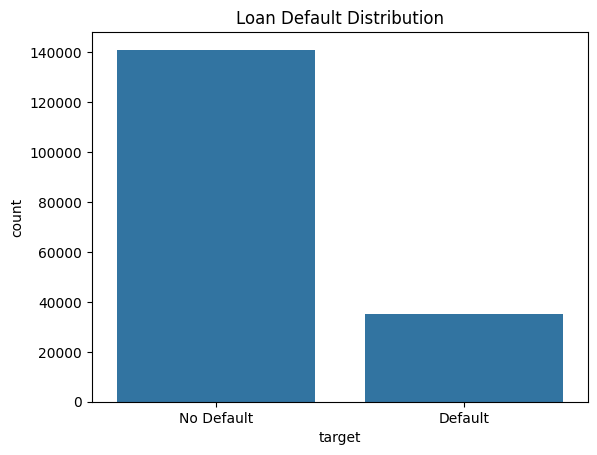

In [66]:
import matplotlib.pyplot as plt   # plotting library
import seaborn as sns              # prettier plots

sns.countplot(x='target', data=df)        # bar chart of default vs no default
plt.title('Loan Default Distribution')    # chart title
plt.xticks([0,1], ['No Default', 'Default'])  # readable x axis labels
plt.show()                                # display the chart

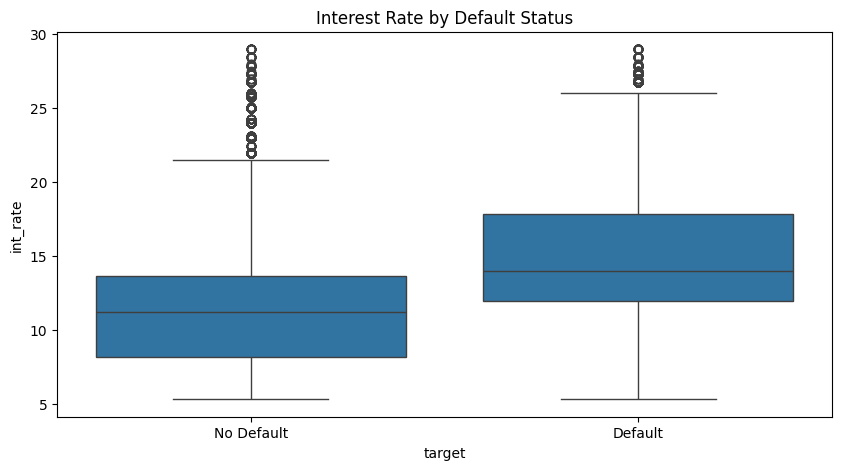

In [67]:
plt.figure(figsize=(10,5))
# creates a blank figure/canvas
# figsize=(10,5) = width 10 inches, height 5 inches
# makes chart bigger and easier to read

sns.boxplot(x='target', y='int_rate', data=df)
# boxplot shows the DISTRIBUTION of a number column
# x='target' = split by default vs no default
# y='int_rate' = show interest rate values
# so we get two boxes — one for each group

plt.title('Interest Rate by Default Status')
# adds title to chart

plt.xticks([0,1], ['No Default', 'Default'])
# renames 0 and 1 to readable labels

plt.show()
# displays the chart

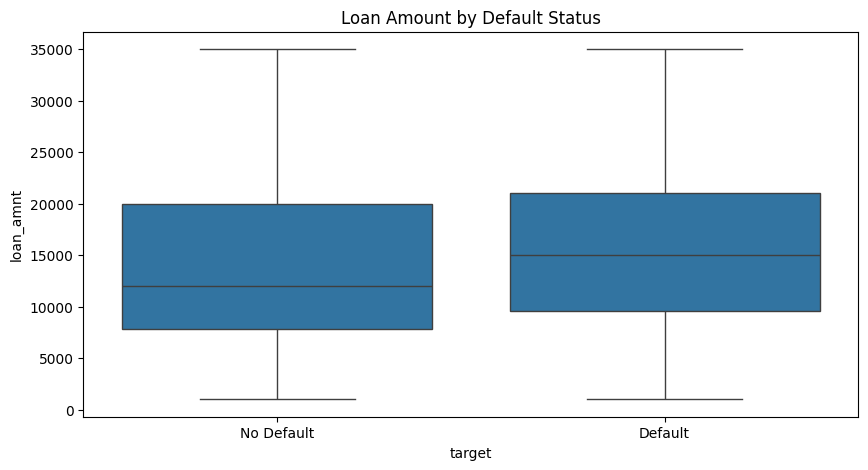

In [68]:
plt.figure(figsize=(10,5))
# creates a blank canvas
# width 10 inches, height 5 inches

sns.boxplot(x='target', y='loan_amnt', data=df)
# boxplot comparing loan amount
# x='target' = split by default vs no default
# y='loan_amnt' = show loan amount values

plt.title('Loan Amount by Default Status')
# adds title to chart

plt.xticks([0,1], ['No Default', 'Default'])
# renames 0 and 1 to readable labels

plt.show()
# displays the chart

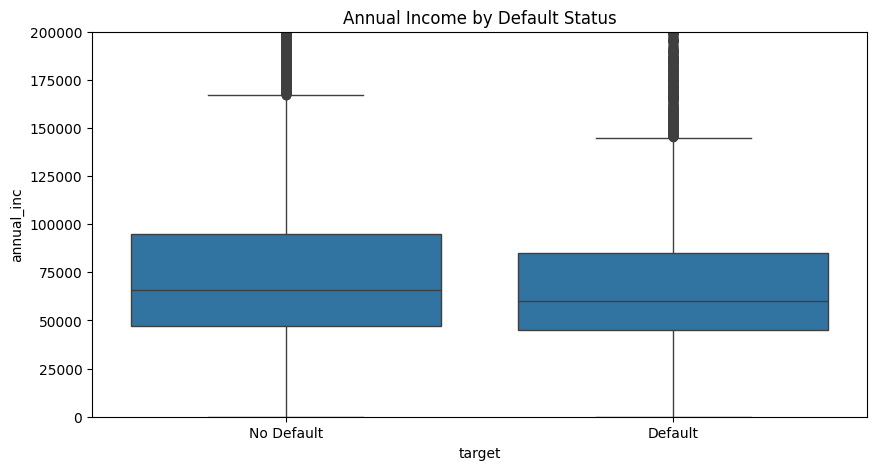

In [69]:
plt.figure(figsize=(10,5))
# creates blank canvas, width 10, height 5 inches

sns.boxplot(x='target', y='annual_inc', data=df)
# boxplot comparing annual income
# x='target' = split by default vs no default
# y='annual_inc' = show annual income values

plt.title('Annual Income by Default Status')
# adds title to chart

plt.ylim(0, 200000)
# limits y axis from 0 to 200,000
# without this outliers like $10 million income
# will squish the chart and hide the pattern

plt.xticks([0,1], ['No Default', 'Default'])
# renames 0 and 1 to readable labels

plt.show()
# displays the chart

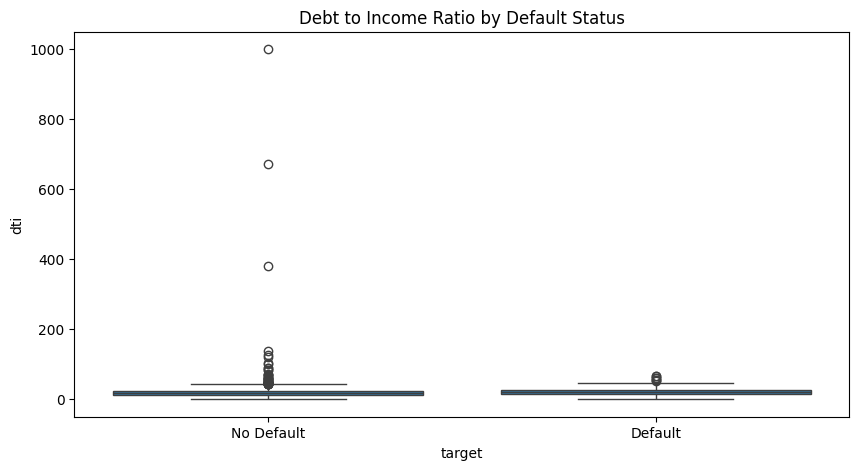

In [70]:
plt.figure(figsize=(10,5))
# creates blank canvas, width 10, height 5 inches

sns.boxplot(x='target', y='dti', data=df)
# boxplot comparing DTI ratio
# x='target' = split by default vs no default
# y='dti' = show DTI values

plt.title('Debt to Income Ratio by Default Status')
# adds title to chart

plt.xticks([0,1], ['No Default', 'Default'])
# renames 0 and 1 to readable labels

plt.show()
# displays the chart

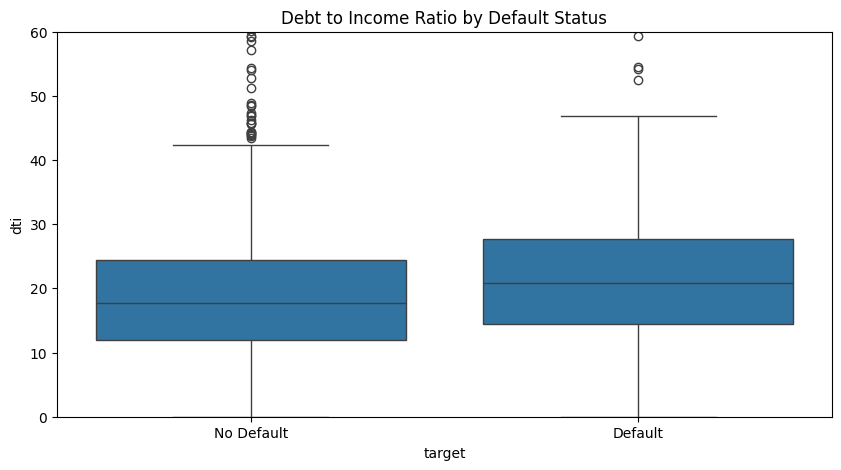

In [71]:
plt.figure(figsize=(10,5))
# creates blank canvas

sns.boxplot(x='target', y='dti', data=df)
# boxplot comparing DTI ratio

plt.title('Debt to Income Ratio by Default Status')
# adds title

plt.ylim(0, 60)
# THIS IS THE FIX!
# limits y axis from 0 to 60 only
# cuts off extreme outliers so we can see the real pattern
# normal DTI is between 0-50 in real life

plt.xticks([0,1], ['No Default', 'Default'])
# renames labels

plt.show()
# displays chart

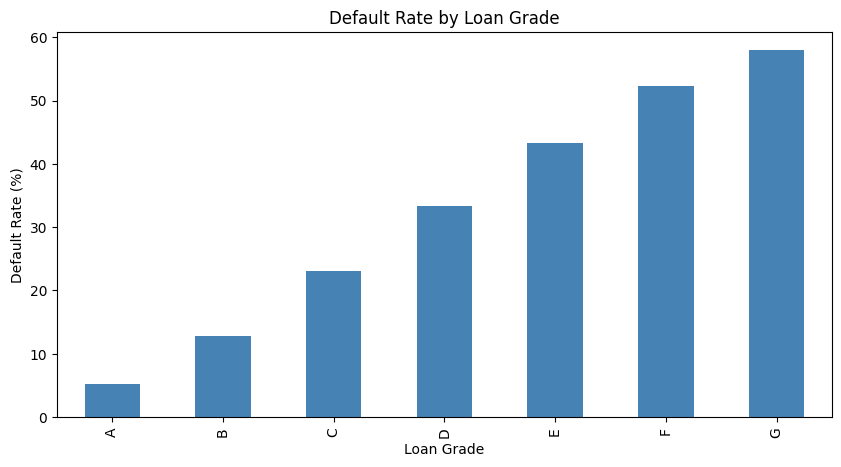

In [72]:
plt.figure(figsize=(10,5))
# creates blank canvas, width 10, height 5 inches

default_rate = df.groupby('grade')['target'].mean() * 100
# groupby('grade') = group all rows by their grade (A,B,C,D,E,F,G)
# ['target'].mean() = calculate average of target in each group
# since target is 0 or 1, mean = percentage of defaults
# × 100 = convert to percentage

default_rate.plot(kind='bar', color='steelblue')
# plot as a bar chart
# kind='bar' = vertical bar chart
# color='steelblue' = blue color bars

plt.title('Default Rate by Loan Grade')
# adds title

plt.xlabel('Loan Grade')
# labels x axis

plt.ylabel('Default Rate (%)')
# labels y axis

plt.show()
# displays chart

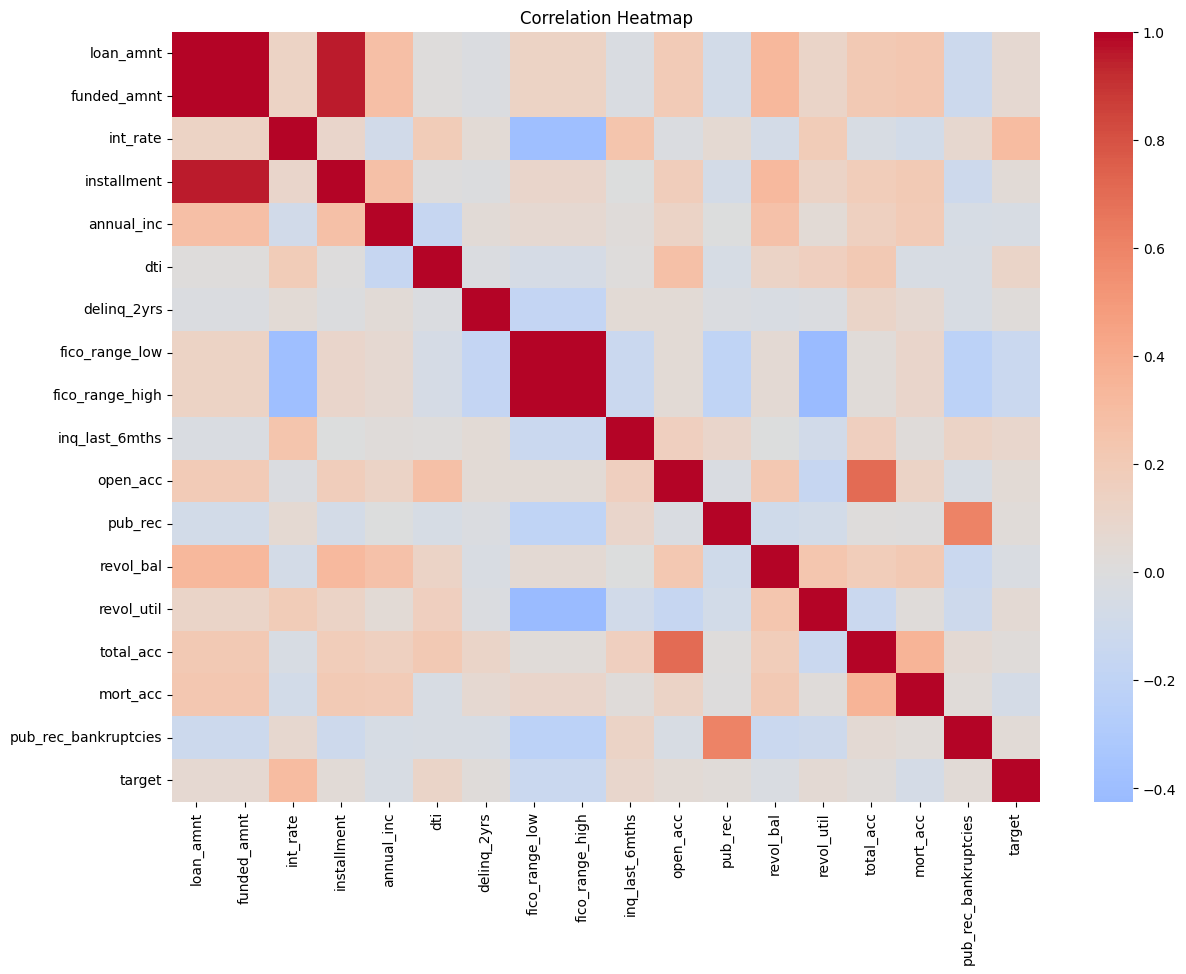

In [73]:
plt.figure(figsize=(14,10))
# bigger canvas needed — lots of columns to show

numeric_df = df.select_dtypes(include='number')
# select ONLY numerical columns
# removes text columns like grade, purpose etc
# heatmap only works with numbers

correlation = numeric_df.corr()
# calculates correlation between every pair of columns
# produces a table of correlation values

sns.heatmap(correlation,
            annot=False,
            cmap='coolwarm',
            center=0)
# draws the heatmap
# annot=False = don't show numbers (too crowded)
# cmap='coolwarm' = red for positive, blue for negative
# center=0 = white color at zero correlation

plt.title('Correlation Heatmap')
# adds title

plt.show()
# displays chart


# DATA **CLEANING**

In [74]:
df = df.drop(columns=['funded_amnt', 'fico_range_high'])
# drop() = removes columns from dataframe
# columns=[...] = list of columns to remove
# funded_amnt → redundant with loan_amnt
# fico_range_high → redundant with fico_range_low

df.shape
# verify columns were dropped
# should now show 23 columns instead of 25

(176082, 23)

In [75]:
import numpy as np
# numpy is a numerical computing library
# we need it for mathematical operations

# check DTI before cleaning
print("Before:", df['dti'].max())
# prints the maximum DTI value currently

# remove rows where DTI is above 100
# DTI above 100 means debt is more than income = impossible
df = df[df['dti'] <= 100]
# df[condition] = keep only rows where condition is TRUE
# df['dti'] <= 100 = keep rows where DTI is 100 or less

# check DTI after cleaning
print("After:", df['dti'].max())
# should now show maximum of 100

df.shape
# verify how many rows remain

Before: 999.0
After: 90.0


(176074, 23)

In [76]:
# check unique values in each text column
for col in ['term', 'emp_length', 'home_ownership',
            'verification_status', 'purpose']:
# for loop = go through each column one by one
# col = current column name in each loop

    print(f"\n{col}:")
    # f"..." = formatted string, shows column name

    print(df[col].unique())
    # unique() = shows all different values in column


term:
[' 36 months' ' 60 months']

emp_length:
['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year' 'Unknown']

home_ownership:
['MORTGAGE' 'RENT' 'OWN' 'ANY']

verification_status:
['Not Verified' 'Source Verified' 'Verified']

purpose:
['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy' 'wedding']


In [77]:
df['term'] = df['term'].str.strip()
# str.strip() = removes extra spaces from both sides
# ' 36 months' → '36 months'

df['term'] = df['term'].str.replace(' months', '')
# str.replace() = replaces text with something else
# removes the word 'months'
# '36 months' → '36'

df['term'] = df['term'].astype(int)
# astype(int) = converts text '36' to number 36
# now term is a proper number column

df['term'].unique()
# verify the result

array([36, 60])

In [78]:
df['emp_length'] = df['emp_length'].str.replace(' years', '')
# removes the word 'years'
# '3 years' → '3'

df['emp_length'] = df['emp_length'].str.replace(' year', '')
# removes singular 'year'
# '1 year' → '1'

df['emp_length'] = df['emp_length'].str.replace('< 1', '0')
# '< 1 year' means less than 1 year
# we treat it as 0 years experience

df['emp_length'] = df['emp_length'].str.replace('+', '')
# '10+' → '10'
# removes the + sign

df['emp_length'] = df['emp_length'].str.replace('Unknown', '0')
# treat unknown as 0

df['emp_length'] = df['emp_length'].astype(int)
# convert text to number

df['emp_length'].unique()
# verify result

array([10,  3,  4,  6,  7,  8,  2,  5,  9,  0,  1])

In [79]:
df = pd.get_dummies(df,
                    columns=['home_ownership',
                             'verification_status',
                             'purpose'],
                    drop_first=True)
# get_dummies() = one hot encoding function in pandas
# columns=[...] = which columns to encode
# drop_first=True = removes first category to avoid redundancy

df.shape
# verify how many columns we now have

(176074, 37)

In [80]:
df.dtypes.value_counts()
# check all column types
# everything should be numbers now

,count
bool,17
float64,15
int64,3
object,2


In [81]:
df.select_dtypes(include='object').columns
# select_dtypes() = filter columns by data type
# include='object' = show only text columns
# .columns = show their names

Index(['grade', 'sub_grade'], dtype='object')

In [82]:
# define order for grade manually
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
# list of grades from best to worst

df['grade'] = df['grade'].map(
    {grade: i for i, grade in enumerate(grade_order)})
# map() = replace each value with a number
# enumerate() = gives index number to each item
# A→0, B→1, C→2, D→3, E→4, F→5, G→6

# define order for sub_grade manually
sub_grades = sorted(df['sub_grade'].unique())
# sorted() = sorts alphabetically
# A1, A2, A3, A4, A5, B1, B2...

df['sub_grade'] = df['sub_grade'].map(
    {sg: i for i, sg in enumerate(sub_grades)})
# same logic as grade
# A1→0, A2→1, A3→2...

# verify
print(df['grade'].unique())
print(df['sub_grade'].unique())

[2 1 5 0 4 3 6]
[13 10  8 25 12  6  5  1  9 11 21  3 22 14  0 18 27 15  7 17 19  4 26 23
 16 20 29 24  2 31 30 32 33 28 34]


In [83]:
df.dtypes.value_counts()
# should show ZERO object columns now


,count
bool,17
float64,15
int64,5


# **Feature Engineering**

In [84]:
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']
# loan amount divided by annual income
# higher = harder to repay = more likely to default

df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12)
# monthly installment divided by monthly income
# annual_inc / 12 = converts yearly income to monthly
# higher = more financial stress = more likely to default

df['fico_avg'] = df['fico_range_low']
# we already dropped fico_range_high earlier
# so we just use fico_range_low as our credit score feature

df.shape
# should show 39 columns now

(176074, 40)

# **Preprocessing**

In [85]:
X = df.drop(columns=['target'])
# drop target column from df
# everything remaining = input features
# X has 38 columns (39 - 1 target)

y = df['target']
# extract only the target column
# y has 0s and 1s only

print("X shape:", X.shape)
# shows rows and feature columns

print("y shape:", y.shape)
# shows rows and target column

print("Default rate:", y.mean().round(3))
# mean of 0s and 1s = percentage of defaults
# round(3) = show 3 decimal places

X shape: (176074, 39)
y shape: (176074,)
Default rate: 0.199


In [86]:
from sklearn.model_selection import train_test_split
# import the splitting function from sklearn library

X_train, X_test, y_train, y_test = train_test_split(
                    X, y,
                    test_size=0.2,
                    random_state=42,
                    stratify=y)
# train_test_split() = splits data into train and test
# X, y = our features and target
# test_size=0.2 = 20% goes to test, 80% to train
# random_state=42 = ensures same split every time
# stratify=y = keeps same 80:20 default ratio
#              in both train and test sets

X_train.shape, X_test.shape
# verify the split

((140859, 39), (35215, 39))

In [87]:
import numpy as np

# replace infinity values with NaN first
X = X.replace([np.inf, -np.inf], np.nan)
# np.inf = positive infinity
# -np.inf = negative infinity
# replace both with NaN

# check how many NaN values we have now
X.isnull().sum().sum()
# should show small number

np.int64(4)

In [88]:
# fill NaN values with median of each column
X = X.fillna(X.median())
# fillna() = fills NaN values
# X.median() = median of each column
# safe choice for financial data

# verify no infinity or NaN remaining
import numpy as np
print("Infinity values:", np.isinf(X).sum().sum())
print("NaN values:", X.isnull().sum().sum())

Infinity values: 0
NaN values: 0


In [89]:
import numpy as np

# check which columns still have infinity
inf_cols = X.columns[np.isinf(X).any()]
# np.isinf() = checks for infinity values
# .any() = finds columns with at least one infinity
# shows column names with infinity

print("Columns with infinity:", inf_cols)
print("Total infinity values:", np.isinf(X).sum().sum())
print("Total NaN values:", X.isnull().sum().sum())

Columns with infinity: Index([], dtype='object')
Total infinity values: 0
Total NaN values: 0


In [90]:
# convert all columns to float64
X = X.astype('float64')
# astype('float64') = converts every column
# to standard decimal number format
# fixes boolean and mixed type issues

# verify
X.dtypes.value_counts()

,count
float64,39


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# redo split with clean X
X_train, X_test, y_train, y_test = train_test_split(
                    X, y,
                    test_size=0.2,
                    random_state=42,
                    stratify=y)
# splitting clean float64 data

scaler = StandardScaler()
# creates scaler object

X_train = scaler.fit_transform(X_train)
# fit and transform on training data only

X_test = scaler.transform(X_test)
# transform test data using same scaler

print("✅ Scaling done!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

✅ Scaling done!
X_train shape: (140859, 39)
X_test shape: (35215, 39)


In [92]:
from imblearn.over_sampling import SMOTE
# import SMOTE from imbalanced-learn library

smote = SMOTE(random_state=42)
# creates SMOTE object
# random_state=42 = reproducible results

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
# fit_resample() = applies SMOTE to training data
# creates synthetic minority class examples
# ONLY apply to training data — NEVER test data!

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 112787, 1: 28072}
After SMOTE: {0: 112787, 1: 112787}


#**Model Building**

In [93]:
from sklearn.linear_model import LogisticRegression
# import Logistic Regression from sklearn

lr_model = LogisticRegression(random_state=42, max_iter=1000)
# creates Logistic Regression model
# random_state=42 = reproducible results
# max_iter=1000 = maximum iterations to converge

lr_model.fit(X_train_sm, y_train_sm)
# fit() = train the model
# X_train_sm = SMOTE balanced training features
# y_train_sm = SMOTE balanced training target

print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [94]:
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              confusion_matrix)
# importing 3 evaluation tools from sklearn
# classification_report = precision, recall, f1 score
# roc_auc_score = AUC-ROC score
# confusion_matrix = table of correct/wrong predictions

y_pred_lr = lr_model.predict(X_test)
# predict() = model predicts on unseen test data
# X_test = 20% data model never saw before
# y_pred_lr = predicted 0s and 1s

print("AUC-ROC:", roc_auc_score(y_test, y_pred_lr).round(3))
# roc_auc_score = measures model's ability
# to distinguish between classes
# closer to 1.0 = better model

print("\n", classification_report(y_test, y_pred_lr))
# shows precision, recall, f1 for each class

AUC-ROC: 0.676

               precision    recall  f1-score   support

           0       0.89      0.70      0.78     28197
           1       0.35      0.65      0.46      7018

    accuracy                           0.69     35215
   macro avg       0.62      0.68      0.62     35215
weighted avg       0.78      0.69      0.72     35215



In [95]:
from sklearn.ensemble import RandomForestClassifier
# import Random Forest from sklearn

rf_model = RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1)
# n_estimators=100 = build 100 decision trees
# random_state=42  = reproducible results
# n_jobs=-1        = use all CPU cores
#                    makes training faster

rf_model.fit(X_train_sm, y_train_sm)
# train model on SMOTE balanced data

print("✅ Random Forest trained!")

✅ Random Forest trained!


In [96]:
y_pred_rf = rf_model.predict(X_test)
# predict on unseen test data
# using trained random forest model

print("AUC-ROC:", roc_auc_score(y_test, y_pred_rf).round(3))
# AUC-ROC score — higher than 0.671 = better than baseline

print("\n", classification_report(y_test, y_pred_rf))
# precision, recall, f1 for each class
# focus on Class 1 (defaulters) scores

AUC-ROC: 0.591

               precision    recall  f1-score   support

           0       0.83      0.94      0.88     28197
           1       0.50      0.24      0.33      7018

    accuracy                           0.80     35215
   macro avg       0.67      0.59      0.61     35215
weighted avg       0.77      0.80      0.77     35215



In [97]:
from xgboost import XGBClassifier
# import XGBoost classifier

xgb_model = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            verbosity=0)
# n_estimators=100  = build 100 trees
# learning_rate=0.1 = how fast model learns
#                     too high = overshoots
#                     too low  = too slow
# max_depth=5       = how deep each tree grows
#                     deeper = more complex
# random_state=42   = reproducible results
# n_jobs=-1         = use all CPU cores
# eval_metric='logloss' = evaluation metric
# verbosity=0       = no extra output messages

xgb_model.fit(X_train_sm, y_train_sm)
# train on SMOTE balanced data

print("✅ XGBoost trained!")

✅ XGBoost trained!


In [98]:
y_pred_xgb = xgb_model.predict(X_test)
# predict on unseen test data
# using trained XGBoost model

print("AUC-ROC:", roc_auc_score(y_test, y_pred_xgb).round(3))
# AUC-ROC score
# we want this higher than 0.671 (Logistic Regression)

print("\n", classification_report(y_test, y_pred_xgb))
# precision, recall, f1 for each class
# focus on Class 1 (defaulters) scores

AUC-ROC: 0.598

               precision    recall  f1-score   support

           0       0.84      0.94      0.88     28197
           1       0.52      0.26      0.34      7018

    accuracy                           0.80     35215
   macro avg       0.68      0.60      0.61     35215
weighted avg       0.77      0.80      0.78     35215



In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Step 1 — fresh split
X_train, X_test, y_train, y_test = train_test_split(
                    X, y,
                    test_size=0.2,
                    random_state=42,
                    stratify=y)

# Step 2 — scale AFTER split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3 — apply SMOTE on scaled training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(
                          X_train_scaled, y_train)

print("✅ Pipeline fixed!")
print("X_train_sm shape:", X_train_sm.shape)
print("y_train_sm value counts:")
print(y_train_sm.value_counts())

✅ Pipeline fixed!
X_train_sm shape: (225574, 39)
y_train_sm value counts:
target
0    112787
1    112787
Name: count, dtype: int64


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model 1 — Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm, y_train_sm)
print("✅ Logistic Regression trained!")

# Model 2 — Random Forest
rf_model = RandomForestClassifier(n_estimators=100,
                                   random_state=42,
                                   n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)
print("✅ Random Forest trained!")

# Model 3 — XGBoost
xgb_model = XGBClassifier(n_estimators=100,
                           learning_rate=0.1,
                           max_depth=5,
                           random_state=42,
                           n_jobs=-1,
                           eval_metric='logloss',
                           verbosity=0)
xgb_model.fit(X_train_sm, y_train_sm)
print("✅ XGBoost trained!")

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!


In [101]:
from sklearn.metrics import classification_report, roc_auc_score

# evaluate all 3 models on CORRECT test data
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}
# dictionary of all 3 models
# key = model name, value = trained model

for name, model in models.items():
# loop through each model one by one
# name = model name
# model = trained model object

    y_pred = model.predict(X_test_scaled)
    # predict on correctly scaled test data

    auc = roc_auc_score(y_test, y_pred).round(3)
    # calculate AUC-ROC score

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"AUC-ROC: {auc}")
    print(classification_report(y_test, y_pred))
    # print full report for each model


Model: Logistic Regression
AUC-ROC: 0.676
              precision    recall  f1-score   support

           0       0.89      0.70      0.78     28197
           1       0.35      0.65      0.46      7018

    accuracy                           0.69     35215
   macro avg       0.62      0.68      0.62     35215
weighted avg       0.78      0.69      0.72     35215


Model: Random Forest
AUC-ROC: 0.591
              precision    recall  f1-score   support

           0       0.83      0.94      0.88     28197
           1       0.50      0.24      0.33      7018

    accuracy                           0.80     35215
   macro avg       0.67      0.59      0.61     35215
weighted avg       0.77      0.80      0.77     35215


Model: XGBoost
AUC-ROC: 0.598
              precision    recall  f1-score   support

           0       0.84      0.94      0.88     28197
           1       0.52      0.26      0.34      7018

    accuracy                           0.80     35215
   macro avg     

In [102]:
# calculate scale_pos_weight
# = ratio of majority to minority class
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
# counts No Default rows / Default rows
# tells XGBoost how imbalanced data is

print("scale_pos_weight:", round(scale, 2))

xgb_model2 = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            verbosity=0,
            scale_pos_weight=scale)
            # tells model to pay more
            # attention to minority class

xgb_model2.fit(X_train_scaled, y_train)
# train on scaled data WITHOUT SMOTE this time
# scale_pos_weight handles imbalance instead

y_pred_xgb2 = xgb_model2.predict(X_test_scaled)

print("AUC-ROC:", roc_auc_score(y_test, y_pred_xgb2).round(3))
print(classification_report(y_test, y_pred_xgb2))

scale_pos_weight: 4.02
AUC-ROC: 0.681
              precision    recall  f1-score   support

           0       0.89      0.69      0.78     28197
           1       0.35      0.68      0.46      7018

    accuracy                           0.69     35215
   macro avg       0.62      0.68      0.62     35215
weighted avg       0.79      0.69      0.71     35215



In [103]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# get probability scores
y_prob = xgb_model2.predict_proba(X_test_scaled)[:,1]
# probability of default for each customer

# find threshold with best F1 score
precisions, recalls, thresholds = precision_recall_curve(
                                    y_test, y_prob)

# calculate f1 at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / \
            (precisions[:-1] + recalls[:-1] + 1e-10)
# f1 = harmonic mean of precision and recall
# 1e-10 = tiny number to avoid division by zero

# find threshold with highest f1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", round(best_threshold, 3))
print("Best F1 score:", round(best_f1, 3))

# apply best threshold
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("\nAUC-ROC:", roc_auc_score(y_test, y_pred_tuned).round(3))
print(classification_report(y_test, y_pred_tuned))

Best threshold: 0.554
Best F1 score: 0.466

AUC-ROC: 0.677
              precision    recall  f1-score   support

           0       0.88      0.77      0.82     28197
           1       0.39      0.58      0.47      7018

    accuracy                           0.73     35215
   macro avg       0.63      0.68      0.64     35215
weighted avg       0.78      0.73      0.75     35215



#**Hyperparameter Tuning With Optuna**

In [104]:
!pip install optuna -q
# installs optuna library
# -q = quiet mode, no lengthy output

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
# set_verbosity = controls how much optuna prints
# WARNING = only show important messages
# hides unnecessary trial by trial output

print("✅ Optuna installed!")

✅ Optuna installed!


In [105]:
from sklearn.metrics import roc_auc_score
import optuna

def objective(trial):
    # objective = function optuna tries to maximize
    # trial = one experiment with one set of parameters

    params = {
        'n_estimators': trial.suggest_int(
                        'n_estimators', 50, 300),
        # suggest_int = try integer values between 50-300

        'learning_rate': trial.suggest_float(
                        'learning_rate', 0.01, 0.3),
        # suggest_float = try decimal values between 0.01-0.3

        'max_depth': trial.suggest_int(
                        'max_depth', 3, 9),
        # try tree depth between 3-9

        'subsample': trial.suggest_float(
                        'subsample', 0.6, 1.0),
        # try subsample ratio between 0.6-1.0

        'colsample_bytree': trial.suggest_float(
                        'colsample_bytree', 0.6, 1.0),
        # try column sample ratio between 0.6-1.0

        'scale_pos_weight': scale,
        # keep our imbalance weight fixed

        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }

    model = XGBClassifier(**params)
    # ** unpacks dictionary as parameters
    # creates XGBoost with trial parameters

    model.fit(X_train_scaled, y_train)
    # train on scaled data

    y_pred = model.predict(X_test_scaled)
    # predict on test data

    return roc_auc_score(y_test, y_pred)
    # return AUC-ROC score
    # optuna tries to MAXIMIZE this

# create and run study
study = optuna.create_study(direction='maximize')
# create_study = creates optimization experiment
# direction='maximize' = we want highest AUC-ROC

study.optimize(objective, n_trials=50)
# optimize = run 50 trials
# each trial tries different parameters

print("✅ Tuning done!")
print("Best AUC-ROC:", round(study.best_value, 3))
print("Best Parameters:", study.best_params)

✅ Tuning done!
Best AUC-ROC: 0.682
Best Parameters: {'n_estimators': 258, 'learning_rate': 0.07430542753261415, 'max_depth': 4, 'subsample': 0.8421126971183923, 'colsample_bytree': 0.627713816221174}


In [110]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# train final model with best optuna parameters
best_model = XGBClassifier(
            n_estimators=74,
            learning_rate=0.03445434096530499,
            max_depth=6,
            subsample=0.647277446634337,
            colsample_bytree=0.7591069423669108,
            scale_pos_weight=scale,
            random_state=42,
            eval_metric='logloss',
            verbosity=0)

best_model.fit(X_train_scaled, y_train)
# train on scaled data

y_pred_final = best_model.predict(X_test_scaled)
# hard predictions (0s and 1s) for confusion matrix

y_prob_final = best_model.predict_proba(X_test_scaled)[:,1]
# probability scores for AUC-ROC and ROC curve

print("✅ Final model trained!")
print("AUC-ROC:", roc_auc_score(y_test, y_prob_final).round(3))
# using y_prob_final → correct AUC-ROC ✅

✅ Final model trained!
AUC-ROC: 0.743


In [113]:
from sklearn.metrics import classification_report

print("=" * 50)
print("FINAL MODEL — FULL EVALUATION REPORT")
print("=" * 50)
# decorative separator lines
# makes output clean and readable

print("\nAUC-ROC:", roc_auc_score(
        y_test, y_prob_final).round(3))
# correct AUC-ROC using probabilities

print("\n", classification_report(
        y_test, y_pred_final,
        target_names=['No Default', 'Default']))
# classification_report = full metrics table
# y_test = actual values
# y_pred_final = predicted values
# target_names = readable class names

FINAL MODEL — FULL EVALUATION REPORT

AUC-ROC: 0.743

               precision    recall  f1-score   support

  No Default       0.89      0.68      0.77     28197
     Default       0.34      0.68      0.45      7018

    accuracy                           0.68     35215
   macro avg       0.62      0.68      0.61     35215
weighted avg       0.78      0.68      0.71     35215



# **Evaluation**

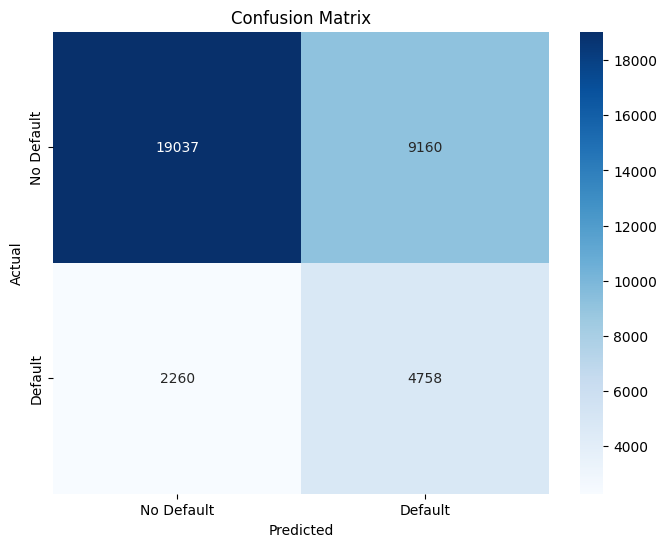

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)
# confusion_matrix() = creates 2x2 table
# y_test = actual values
# y_pred_final = predicted values

plt.figure(figsize=(8,6))
# creates blank canvas

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
# heatmap = colored table
# annot=True = show numbers inside boxes
# fmt='d' = show as whole numbers
# cmap='Blues' = blue color scheme
# xticklabels = column labels
# yticklabels = row labels

plt.title('Confusion Matrix')
# adds title

plt.ylabel('Actual')
# y axis label

plt.xlabel('Predicted')
# x axis label

plt.show()
# display chart

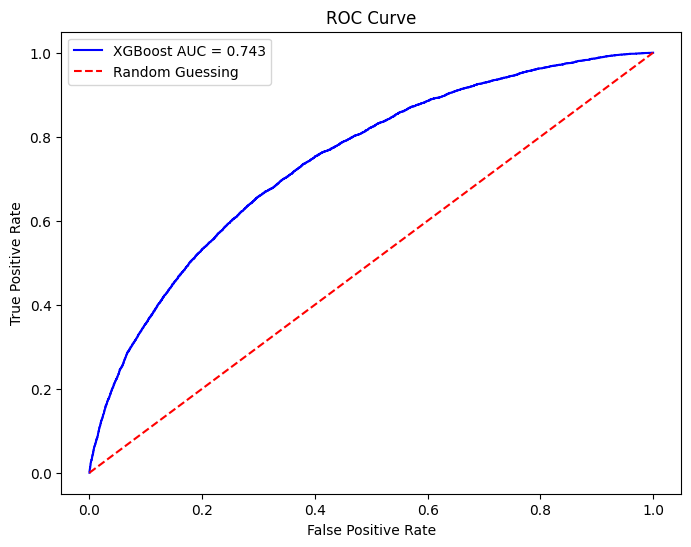

In [115]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
# roc_curve() = calculates points to draw ROC curve
# fpr = False Positive Rate at each threshold
# tpr = True Positive Rate at each threshold
# thresholds = all possible threshold values

auc_score = roc_auc_score(y_test, y_prob_final).round(3)
# calculates area under the curve

plt.figure(figsize=(8,6))
# blank canvas

plt.plot(fpr, tpr,
         color='blue',
         label=f'XGBoost AUC = {auc_score}')
# plots the ROC curve
# fpr on x axis, tpr on y axis
# label shows AUC score in legend

plt.plot([0,1], [0,1],
         color='red',
         linestyle='--',
         label='Random Guessing')
# plots diagonal line
# represents random guessing baseline

plt.title('ROC Curve')
# title

plt.xlabel('False Positive Rate')
# x axis label

plt.ylabel('True Positive Rate')
# y axis label

plt.legend()
# shows label box on chart

plt.show()
# display chart

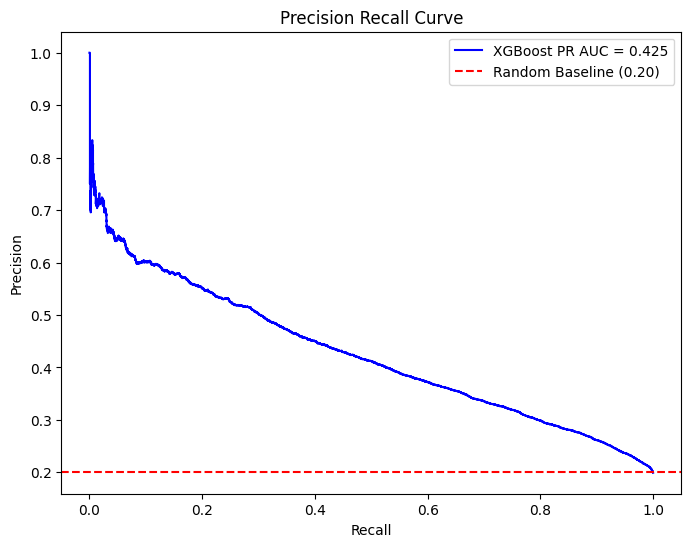

In [114]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(
                                    y_test, y_prob_final)
# calculates precision and recall
# at every possible threshold value
# precision = array of precision values
# recall = array of recall values

pr_auc = auc(recall, precision).round(3)
# auc() = calculates area under PR curve
# higher = better model

plt.figure(figsize=(8,6))
# blank canvas

plt.plot(recall, precision,
         color='blue',
         label=f'XGBoost PR AUC = {pr_auc}')
# plots precision recall curve
# recall on x axis
# precision on y axis

plt.axhline(y=0.20,
            color='red',
            linestyle='--',
            label='Random Baseline (0.20)')
# axhline = horizontal line
# y=0.20 = default rate in our data
# represents random classifier baseline

plt.title('Precision Recall Curve')
# title

plt.xlabel('Recall')
# x axis label

plt.ylabel('Precision')
# y axis label

plt.legend()
# shows label box

plt.show()
# display chart

# ** SHAP Explainability**

In [116]:
!pip install shap -q
# installs shap library
# -q = quiet mode

import shap
# imports shap library

print("✅ SHAP installed!")

✅ SHAP installed!


In [117]:
explainer = shap.TreeExplainer(best_model)
# TreeExplainer = SHAP explainer for tree models
# works perfectly with XGBoost
# best_model = our trained XGBoost model

shap_values = explainer.shap_values(X_test_scaled)
# calculate SHAP values for test data
# shap_values = how much each feature
# contributed to each prediction
# positive = pushed towards default
# negative = pushed away from default

print("✅ SHAP values calculated!")
print("Shape:", shap_values.shape)
# should match X_test shape
# (35215, 38)

✅ SHAP values calculated!
Shape: (35215, 39)


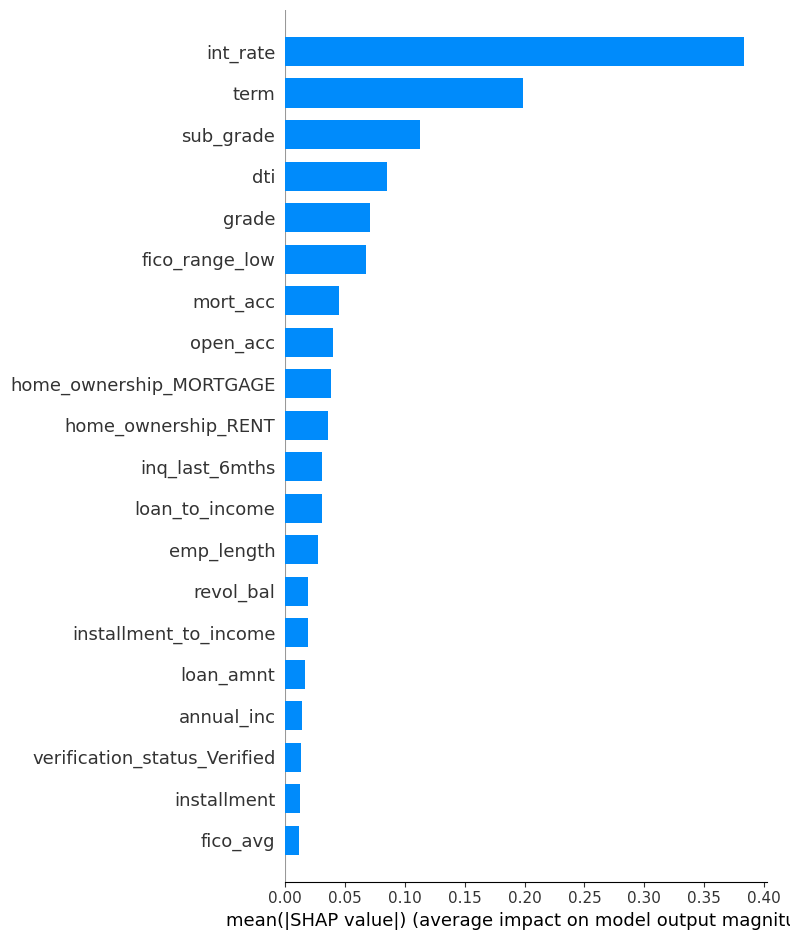

In [118]:
plt.figure(figsize=(10,8))
# blank canvas, bigger size needed

# get feature names
feature_names = list(X.columns)
# X.columns = column names of our features
# list() = converts to list format

shap.summary_plot(shap_values,
                  X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=True)
# summary_plot = shows feature importance
# shap_values = calculated SHAP values
# X_test_scaled = test data
# feature_names = column names
# plot_type='bar' = horizontal bar chart
# show=True = display immediately


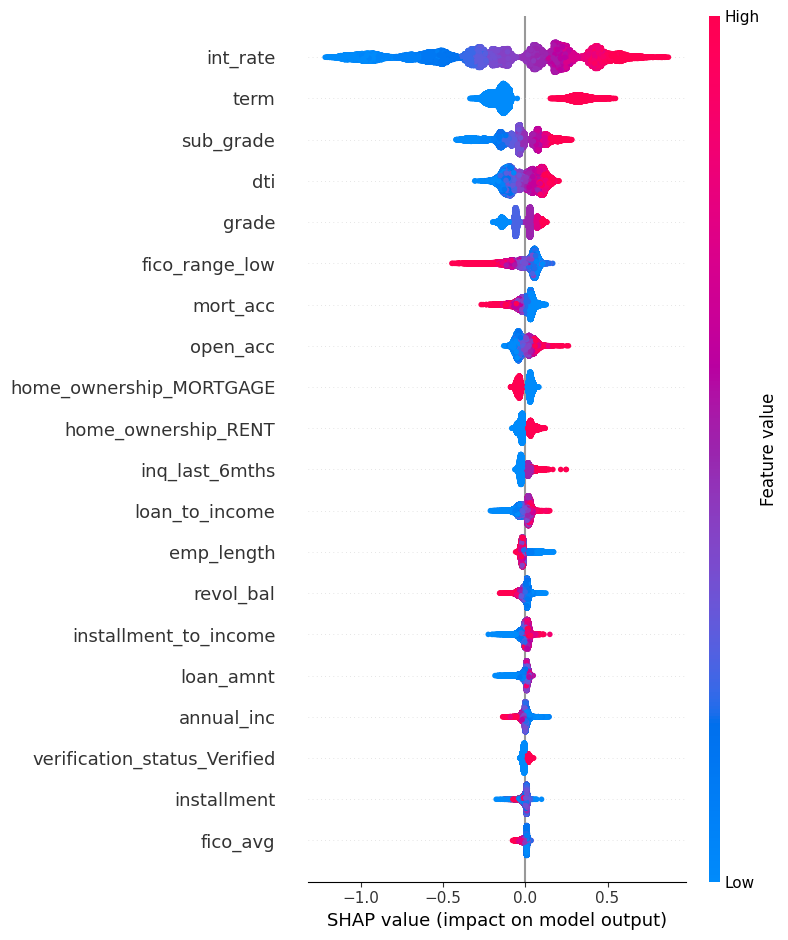

In [119]:
plt.figure(figsize=(10,8))
# blank canvas

shap.summary_plot(shap_values,
                  X_test_scaled,
                  feature_names=feature_names,
                  plot_type='dot',
                  show=True)
# same as before but plot_type='dot'
# dot = shows direction AND importance
# each dot = one customer in test data
# color = feature value (red=high, blue=low)
# position on x axis = impact on prediction

In [120]:
import pickle

# save best model
with open('loan_default_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
# pickle = saves Python object to file
# 'wb' = write binary mode
# saves our trained XGBoost model

# save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
# saves our fitted scaler
# needed to scale new customer data

# save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
# saves column names
# needed to match input format

print("✅ Model saved!")
print("✅ Scaler saved!")
print("✅ Feature names saved!")

✅ Model saved!
✅ Scaler saved!
✅ Feature names saved!


In [121]:
from google.colab import files

# download all 3 files to your laptop
files.download('loan_default_model.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
